# MOFA Latent Factor Model

MOFA-derived latent factors used as compact input features, in place of raw omics data.

In [1]:
import os
# working directory: run this notebook from the MLPipeline folder
print(os.getcwd())


C:\Users\sshor\Desktop\Data Science\NEWPROJECT\ML Scripts


## 1. Imports

In [2]:
import common_utils as cu


## 2. Configuration

Note: with only 15 MOFA factors as input (vs. thousands of raw features), DEBUG_MODE's feature-subsetting has nothing to shrink -- it will simply keep all 15. Only the sample-count subsetting still applies. This means DEBUG_MODE mainly verifies plumbing/code correctness here, not runtime -- the full run should already be fast given so few features.

In [3]:
cu.CONFIG["debug_mode"] = False  # <-- flip to False for the real, full-scale run

cu.CONFIG["reference_cohort_dir"] = "reference_cohort"
MOFA_FACTORS_FILE = "../MOFA/data/mofa_sample_factor_matrix.csv"

EXPERIMENT_NAME = "mofa"


## 3. Load MOFA factors

Restricted automatically to the fixed reference cohort. Note the MOFA matrix may cover MORE samples than your reference cohort (e.g. it was trained on a larger pool) -- that's fine, `load_reference_cohort` intersects down to your fixed 318-sample cohort automatically.

**Sanity check:** confirm the sample count matches your other two experiments (318, or the DEBUG_MODE subset count) -- if it's much smaller, something about sample ID formatting may not be matching (e.g. barcode suffix differences).

In [4]:
X, y, fold_arr, samples, feature_names = cu.load_reference_cohort(feature_file=MOFA_FACTORS_FILE)
print("Feature names (factors):", list(feature_names))


Loaded 318 samples x 15 features, 5 folds.
Feature names (factors): ['Factor_1', 'Factor_2', 'Factor_3', 'Factor_4', 'Factor_5', 'Factor_6', 'Factor_7', 'Factor_8', 'Factor_9', 'Factor_10', 'Factor_11', 'Factor_12', 'Factor_13', 'Factor_14', 'Factor_15']


## 4. Run cross-validation

Same models, same folds, same metrics as the other two experiments -- only the input differs.

In [5]:
print(cu.MODEL_REGISTRY.keys())

dict_keys(['coxnet', 'rsf', 'xgboost'])


In [6]:
results = cu.run_cross_validation(X, y, fold_arr, models=("coxnet", "rsf", "xgboost"))


[fold 0] coxnet   C-index=0.638  IBS=0.177  (alpha=0.01838)
[fold 0] rsf      C-index=0.632  IBS=0.172
[fold 0] xgboost  C-index=0.704  IBS=0.173
[fold 1] coxnet   C-index=0.640  IBS=0.167  (alpha=0.164)
[fold 1] rsf      C-index=0.624  IBS=0.161
[fold 1] xgboost  C-index=0.585  IBS=0.188
[fold 2] coxnet   C-index=0.747  IBS=0.166  (alpha=0.1495)
[fold 2] rsf      C-index=0.824  IBS=0.136
[fold 2] xgboost  C-index=0.808  IBS=0.146
[fold 3] coxnet   C-index=0.652  IBS=0.166  (alpha=0.178)
[fold 3] rsf      C-index=0.717  IBS=0.147
[fold 3] xgboost  C-index=0.724  IBS=0.161
[fold 4] coxnet   C-index=0.725  IBS=0.170  (alpha=0.0454)
[fold 4] rsf      C-index=0.746  IBS=0.159
[fold 4] xgboost  C-index=0.722  IBS=0.206


## 5. Summary and comparison plot

In [7]:
cu.summarize_results(results)



=== Cross-validated performance (mean +/- std across folds) ===
coxnet    C-index = 0.680 +/- 0.046   IBS = 0.169 +/- 0.004
rsf       C-index = 0.708 +/- 0.075   IBS = 0.155 +/- 0.012
xgboost   C-index = 0.709 +/- 0.072   IBS = 0.175 +/- 0.021


Saved model_comparison_mofa.png


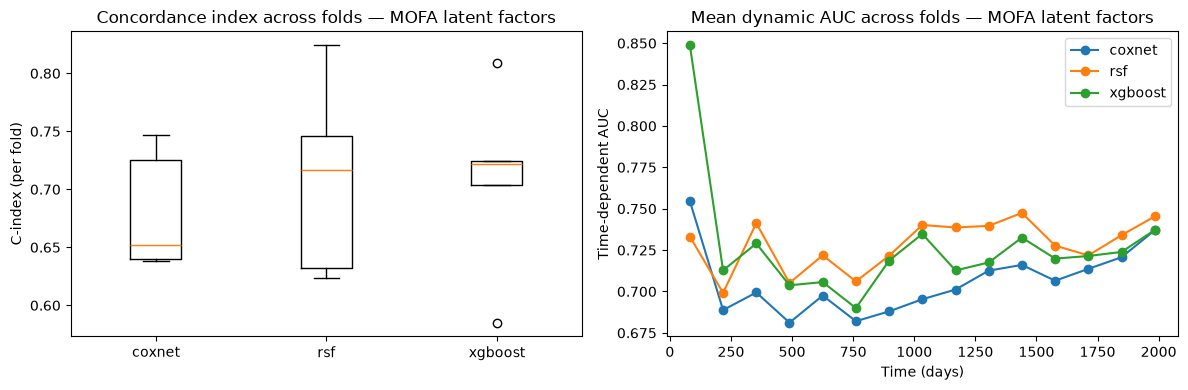

In [8]:
cu.plot_comparison(results, title_suffix=" — MOFA latent factors",
                    save_path=f"model_comparison_{EXPERIMENT_NAME}.png")


## 6. Feature importance

Elastic-Net Cox (full-data refit): alpha=0.1371, 3 nonzero features out of 15


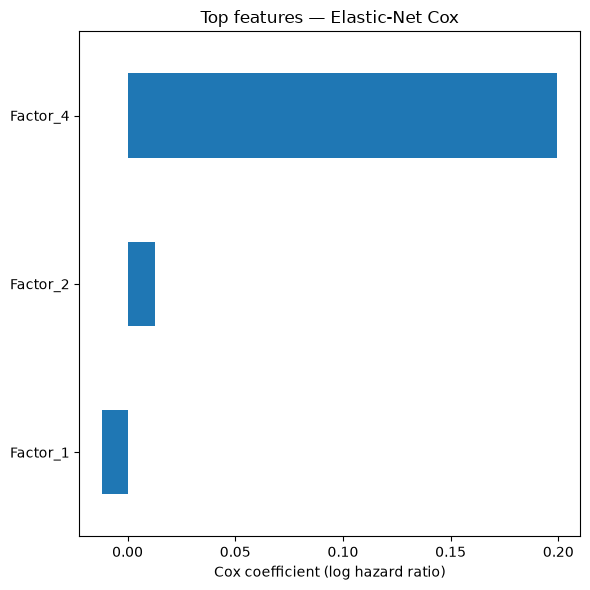

In [9]:
nonzero_coefs = cu.feature_importance_coxnet(X, y, feature_names, save_prefix=EXPERIMENT_NAME)


RSF permutation importance computed on top 15 (by variance) of 15 total features.


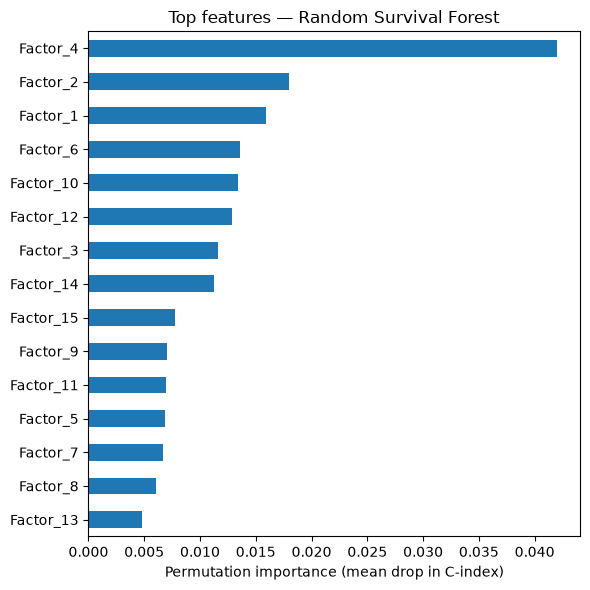

In [10]:
importances_rsf = cu.feature_importance_rsf(X, y, feature_names, save_prefix=EXPERIMENT_NAME)


XGBoost-Cox (full-data refit): 15 features with nonzero importance out of 15


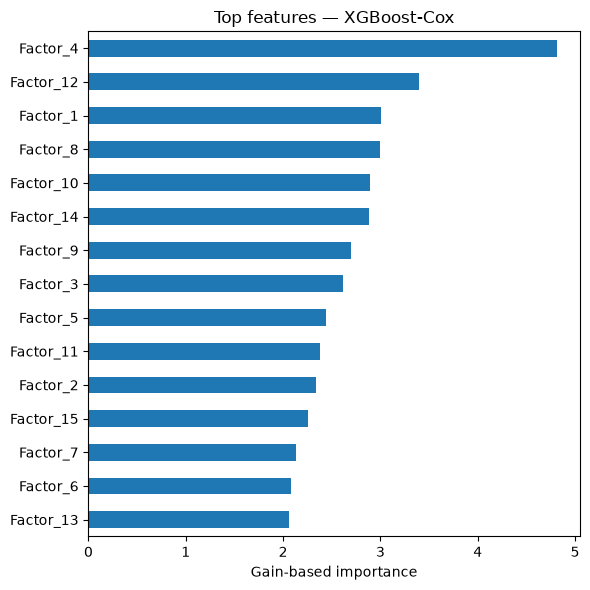

In [11]:
xgb_importances = cu.feature_importance_xgboost(X, y, feature_names, save_prefix=EXPERIMENT_NAME)

## 7. Interpreting top factors biologically
needed for annotation later

In [17]:
loadings = pd.read_csv("../MOFA/data/mofa_top_500_features_per_factor.csv")
top_factor_name = nonzero_coefs.index[0]
print(loadings[loadings["Factor"] == top_factor_name].head(20))

        Factor         View     Feature_Name  Raw_Weight  Absolute_Weight  \
1500  Factor_4  Methylation  cg05911774_meth   -0.049879         0.049879   
1501  Factor_4  Methylation  cg00952054_meth   -0.049870         0.049870   
1502  Factor_4  Methylation  cg15397593_meth   -0.049468         0.049468   
1503  Factor_4  Methylation  cg10682957_meth   -0.048002         0.048002   
1504  Factor_4  Methylation  cg02099572_meth   -0.047919         0.047919   
1505  Factor_4  Methylation  cg06242243_meth   -0.047540         0.047540   
1506  Factor_4  Methylation  cg02689072_meth   -0.046915         0.046915   
1507  Factor_4  Methylation  cg18404706_meth   -0.046810         0.046810   
1508  Factor_4  Methylation  cg04473654_meth   -0.046344         0.046344   
1509  Factor_4  Methylation  cg01457778_meth   -0.045899         0.045899   
1510  Factor_4  Methylation  cg12444411_meth   -0.045884         0.045884   
1511  Factor_4  Methylation  cg17107691_meth   -0.045378         0.045378   

In [18]:
print(loadings.columns.tolist())
loadings.head()

['Factor', 'View', 'Feature_Name', 'Raw_Weight', 'Absolute_Weight', 'Rank']


,Factor,View,Feature_Name,Raw_Weight,Absolute_Weight,Rank
0,Factor_1,Methylation,cg10790704_meth,-0.111078,0.111078,1
1,Factor_1,Methylation,cg16233472_meth,-0.107038,0.107038,2
2,Factor_1,Methylation,cg04428071_meth,-0.096856,0.096856,3
3,Factor_1,Methylation,cg21201401_meth,-0.093932,0.093932,4
4,Factor_1,Methylation,cg14528751_meth,-0.093560,0.093560,5


In [19]:
top_factor_loadings = loadings[loadings["Factor"] == top_factor_name].head(20)
print(f"Top 20 features defining {top_factor_name}:")
print(top_factor_loadings)

Top 20 features defining Factor_4:
        Factor         View     Feature_Name  Raw_Weight  Absolute_Weight  \
1500  Factor_4  Methylation  cg05911774_meth   -0.049879         0.049879   
1501  Factor_4  Methylation  cg00952054_meth   -0.049870         0.049870   
1502  Factor_4  Methylation  cg15397593_meth   -0.049468         0.049468   
1503  Factor_4  Methylation  cg10682957_meth   -0.048002         0.048002   
1504  Factor_4  Methylation  cg02099572_meth   -0.047919         0.047919   
1505  Factor_4  Methylation  cg06242243_meth   -0.047540         0.047540   
1506  Factor_4  Methylation  cg02689072_meth   -0.046915         0.046915   
1507  Factor_4  Methylation  cg18404706_meth   -0.046810         0.046810   
1508  Factor_4  Methylation  cg04473654_meth   -0.046344         0.046344   
1509  Factor_4  Methylation  cg01457778_meth   -0.045899         0.045899   
1510  Factor_4  Methylation  cg12444411_meth   -0.045884         0.045884   
1511  Factor_4  Methylation  cg17107691_m

In [20]:
top_factor_name_rsf = importances_rsf.index[0]
print(f"\nRSF's top factor: {top_factor_name_rsf}")
print(loadings[loadings["Factor"] == top_factor_name_rsf].head(20))


RSF's top factor: Factor_4
        Factor         View     Feature_Name  Raw_Weight  Absolute_Weight  \
1500  Factor_4  Methylation  cg05911774_meth   -0.049879         0.049879   
1501  Factor_4  Methylation  cg00952054_meth   -0.049870         0.049870   
1502  Factor_4  Methylation  cg15397593_meth   -0.049468         0.049468   
1503  Factor_4  Methylation  cg10682957_meth   -0.048002         0.048002   
1504  Factor_4  Methylation  cg02099572_meth   -0.047919         0.047919   
1505  Factor_4  Methylation  cg06242243_meth   -0.047540         0.047540   
1506  Factor_4  Methylation  cg02689072_meth   -0.046915         0.046915   
1507  Factor_4  Methylation  cg18404706_meth   -0.046810         0.046810   
1508  Factor_4  Methylation  cg04473654_meth   -0.046344         0.046344   
1509  Factor_4  Methylation  cg01457778_meth   -0.045899         0.045899   
1510  Factor_4  Methylation  cg12444411_meth   -0.045884         0.045884   
1511  Factor_4  Methylation  cg17107691_meth   -

In [ ]:
# Select top 20 by ABSOLUTE weight (magnitude)
top_factor_loadings = (
    loadings[loadings["Factor"] == top_factor_name]
    .sort_values("Absolute_Weight", ascending=False)
    .head(20)
)
print(f"Top 20 features defining {top_factor_name} (ranked by magnitude):")
print(top_factor_loadings)

Top 20 features defining Factor_4 (ranked by magnitude):
        Factor    View Feature_Name  Raw_Weight  Absolute_Weight  Rank
9000  Factor_4  RNAseq     IGF2_rna    0.556526         0.556526     1
9001  Factor_4  RNAseq    GRIK3_rna    0.549551         0.549551     2
9002  Factor_4  RNAseq     PRND_rna    0.521688         0.521688     3
9003  Factor_4  RNAseq  COL21A1_rna    0.510079         0.510079     4
9004  Factor_4  RNAseq      OGN_rna    0.509496         0.509496     5
9005  Factor_4  RNAseq    SFRP2_rna    0.503890         0.503890     6
9006  Factor_4  RNAseq      FAP_rna    0.499369         0.499369     7
9007  Factor_4  RNAseq     PODN_rna    0.499256         0.499256     8
9008  Factor_4  RNAseq     RGS5_rna    0.496351         0.496351     9
9009  Factor_4  RNAseq    APLNR_rna    0.492630         0.492630    10
9010  Factor_4  RNAseq      ELN_rna    0.490151         0.490151    11
9011  Factor_4  RNAseq      PLN_rna    0.490061         0.490061    12
9012  Factor_4  RNAs

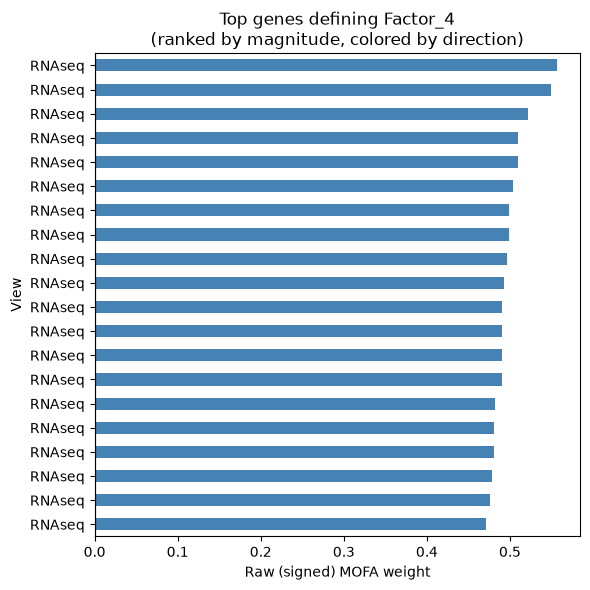

In [23]:
import matplotlib.pyplot as plt

plot_data = top_factor_loadings.set_index(loadings.columns[1])["Raw_Weight"].sort_values()
plt.figure(figsize=(6, 6))
colors = ["crimson" if v < 0 else "steelblue" for v in plot_data.values]
plot_data.plot(kind="barh", color=colors)
plt.xlabel("Raw (signed) MOFA weight")
plt.title(f"Top genes defining {top_factor_name}\n(ranked by magnitude, colored by direction)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(f"mofa_{top_factor_name}_top_loadings.png", dpi=150)
plt.show()

## 8. Save results for the final 3-way comparison (notebook 04)

In [24]:
cu.save_results(EXPERIMENT_NAME, results)


Saved results to results\results_mofa.pkl
